In [1]:
"""
LABEL TOPICS — read keywords + example comments per topic, assign your own names
====================================================================================
BERTopic's auto-generated names (e.g. "0_you_to_the_and") are just the top
keywords — not always meaningful on their own. This prints, for each topic,
the keywords plus several real example comments, so you can read them and
assign a human-readable label.

Usage:
    1. Run this script — it prints keywords + examples per topic to console
       AND writes them to topics_for_labeling.csv for easier reading/editing.
    2. Open topics_for_labeling.csv, add your own label in the empty
       'my_label' column for each topic (e.g. "IT equipment complaints",
       "phishing/security incidents", "career advice - resignation").
    3. Run apply_labels() (bottom of this script) to merge your labels
       back onto comment_topics_assigned.csv as a new 'topic_label' column.

Reads:
    comment_topic_info.csv
    comment_topics_assigned.csv

Writes:
    topics_for_labeling.csv          (fill in 'my_label' column yourself)
    comment_topics_assigned_labeled.csv   (after you run apply_labels())
"""

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/nadia/Desktop/redditRun_june/comment_data/'   # adjust if running elsewhere (e.g. /content/ on Colab)
TOPIC_INFO_FILE = DATA_DIR + 'comment_topic_info.csv'
ASSIGNED_FILE = DATA_DIR + 'comment_topics_assigned.csv'

N_EXAMPLES = 5   # how many example comments to show per topic


def show_topics_for_labeling():
    topic_info = pd.read_csv(TOPIC_INFO_FILE)
    assigned = pd.read_csv(ASSIGNED_FILE)

    topic_info = topic_info.sort_values('Count', ascending=False)

    rows_for_csv = []

    for _, row in topic_info.iterrows():
        topic_id = row['Topic']
        count = row['Count']
        name = row['Name']

        examples = assigned.loc[assigned['topic'] == topic_id, 'body'].dropna()
        examples = examples.sample(min(N_EXAMPLES, len(examples)), random_state=42).tolist()

        print("\n" + "=" * 70)
        print(f"TOPIC {topic_id}  (n={count:,})  auto-name: {name}")
        print("=" * 70)
        for ex in examples:
            snippet = ex[:250].replace('\n', ' ')
            print(f"  • {snippet}")

        rows_for_csv.append({
            'topic': topic_id,
            'n_comments': count,
            'auto_name': name,
            'example_1': examples[0][:300] if len(examples) > 0 else '',
            'example_2': examples[1][:300] if len(examples) > 1 else '',
            'example_3': examples[2][:300] if len(examples) > 2 else '',
            'my_label': '',   # ← fill this in yourself after reading the examples
        })

    out_df = pd.DataFrame(rows_for_csv)
    out_df.to_csv(DATA_DIR + 'topics_for_labeling.csv', index=False)
    print(f"\n\n✓ topics_for_labeling.csv saved — fill in the 'my_label' column, "
          f"then run apply_labels()")


def apply_labels():
    """Run this AFTER you've filled in 'my_label' in topics_for_labeling.csv"""
    labels = pd.read_csv(DATA_DIR + 'topics_for_labeling.csv', usecols=['topic', 'my_label'])
    assigned = pd.read_csv(ASSIGNED_FILE)

    merged = assigned.merge(labels, on='topic', how='left')
    merged = merged.rename(columns={'my_label': 'topic_label'})

    n_unlabeled = merged['topic_label'].isna().sum() + (merged['topic_label'] == '').sum()
    if n_unlabeled > 0:
        print(f"⚠ {n_unlabeled:,} comments have topics with no label filled in yet")

    merged.to_csv(DATA_DIR + 'comment_topics_assigned_labeled.csv', index=False)
    print(f"✓ comment_topics_assigned_labeled.csv saved  →  {len(merged):,} comments")


if __name__ == '__main__':
    show_topics_for_labeling()
    # After filling in topics_for_labeling.csv, uncomment and run:
    # apply_labels()


TOPIC 0  (n=2,244)  auto-name: 0_security_people_team_role
  • Congrats on the job!   Honestly, though you’re just starting out, some certification books can be super informative and helpful. I’m getting my CISM currently and the All-In-One basically walks through standing up an infosec program in certain ways. 
  • While your question is valid it does not related to information security.  [Rule 2]  ***** Depending on your country, laws, and contracts you signed when you were hired it is most your companies work product and out of your control.
  • Which company do you have experience with? FAANG? Fortune? Mid-size?
  • If you think you’re burnt out now and frustrated with talking to people, security and especially security consulting will be doubling down on both scores…
  • I can relate. Changed jobs to IC to learn from more senior folks (as a senior with 10 years experience in security engineering) and those folks left almost immediately after joining. Now just bored out of my mind

VISUALIZE BERTOPIC RESULTS FOR SHARING
⚠ No labeled file found — using auto-generated keyword names instead. Run label_topics_helper.py's apply_labels() first for readable labels.
✓ Saved: /Users/nadia/Desktop/redditRun_june/comment_data/topic_size_barplot_labeled.png
⚠ bat_score column not found — skipping heatmap
⚠ Saved model not found at /Users/nadia/Desktop/redditRun_june/comment_data/bertopic_model — skipping interactive map. (This needs the bertopic_model/ folder saved by the main script.)

DONE — files ready to share:
  topic_size_barplot_labeled.png   (static, for a paper/slide)
  topic_by_batscore_heatmap.png    (static, ties topics to severity)
  intertopic_distance_map.html     (interactive, for exploration)
  topic_hierarchy.html             (interactive, if generated)


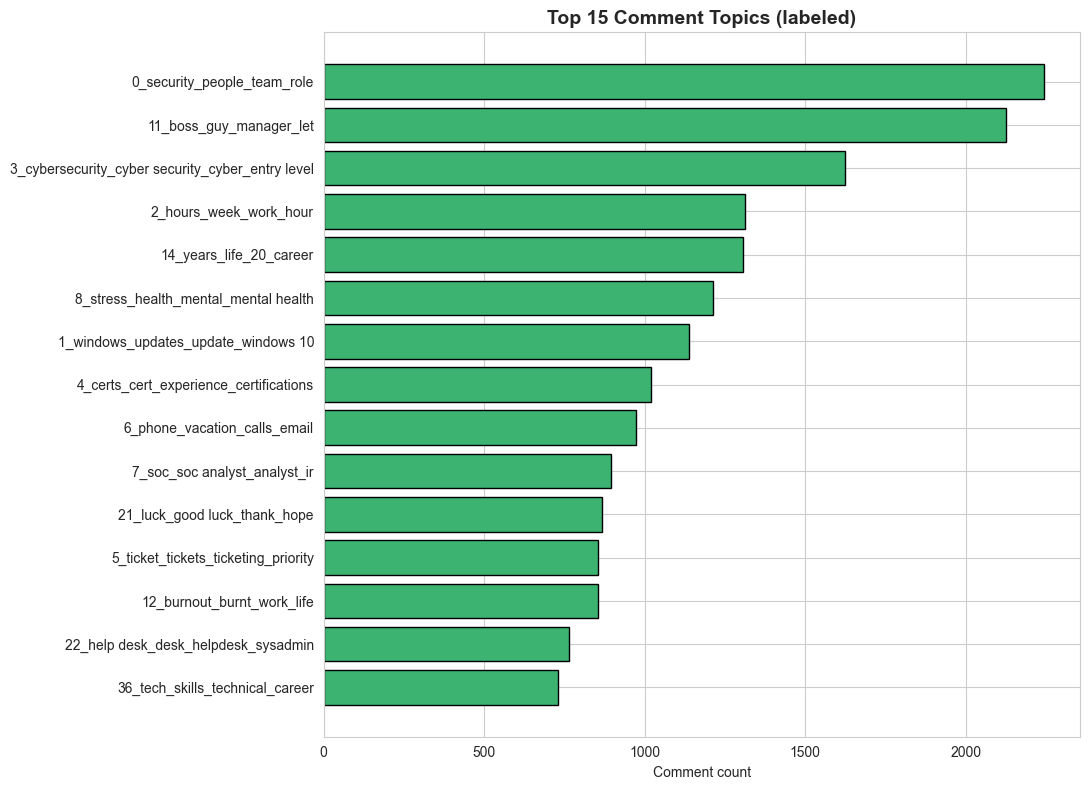

In [2]:
"""
VISUALIZE BERTOPIC RESULTS FOR SHARING WITH OTHER RESEARCHERS
==================================================================
Three outputs, different purposes:

  1. topic_size_barplot_labeled.png
     Clean static bar chart with YOUR human labels (not raw keywords).
     Best for: a paper figure or a slide.

  2. topic_by_batscore_heatmap.png
     % of each bat_score group's comments falling into each topic.
     Best for: showing HOW topics relate to burnout severity — this
     is the one most directly tied to your research question.

  3. intertopic_distance_map.html
     Interactive bubble map (BERTopic's built-in visualize_topics()) —
     topics positioned by similarity, bubble size = topic size.
     Best for: exploratory review in a lab meeting (hover for details).

Requires you've already run apply_labels() from label_topics_helper.py
so comment_topics_assigned_labeled.csv has a 'topic_label' column.
If you haven't labeled topics yet, this falls back to auto-generated
keyword names.

Install once (beyond what BERTopic already needs):
    pip install kaleido --break-system-packages   # for static image export from plotly

Reads:
    comment_topics_assigned_labeled.csv   (falls back to comment_topics_assigned.csv)
    comment_topic_info.csv
    bertopic_model/                        (saved model, for the interactive map)

Writes:
    topic_size_barplot_labeled.png
    topic_by_batscore_heatmap.png
    intertopic_distance_map.html
"""

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR = '/Users/nadia/Desktop/redditRun_june/comment_data/'   # adjust for Colab: /content/
LABELED_FILE = DATA_DIR + 'comment_topics_assigned_labeled.csv'
FALLBACK_FILE = DATA_DIR + 'comment_topics_assigned.csv'
TOPIC_INFO_FILE = DATA_DIR + 'comment_topic_info.csv'
MODEL_DIR = DATA_DIR + 'bertopic_model'
OUTPUT_DIR = DATA_DIR

TOP_N_TOPICS = 15   # how many topics to show in the bar chart / heatmap

sns.set_style("whitegrid")


# ── STEP 1: LOAD (with or without your manual labels) ──────────────────────
def load_data():
    if os.path.exists(LABELED_FILE):
        df = pd.read_csv(LABELED_FILE)
        print("Using your labeled topics (comment_topics_assigned_labeled.csv)")
        label_col = 'topic_label'
    else:
        df = pd.read_csv(FALLBACK_FILE)
        print("⚠ No labeled file found — using auto-generated keyword names instead. "
              "Run label_topics_helper.py's apply_labels() first for readable labels.")
        topic_info = pd.read_csv(TOPIC_INFO_FILE)
        name_map = dict(zip(topic_info['Topic'], topic_info['Name']))
        df['topic_label'] = df['topic'].map(name_map)
        label_col = 'topic_label'

    # Fill any blank/missing labels with the topic number so nothing disappears silently
    df[label_col] = df[label_col].fillna(df['topic'].astype(str))
    df.loc[df[label_col] == '', label_col] = df['topic'].astype(str)

    return df


# ── STEP 2: LABELED BAR CHART ───────────────────────────────────────────────
def make_labeled_barplot(df):
    sizes = df[df['topic'] != -1].groupby('topic_label').size().sort_values(ascending=False).head(TOP_N_TOPICS)

    fig, ax = plt.subplots(figsize=(11, 8))
    ax.barh(sizes.index, sizes.values, color='mediumseagreen', edgecolor='black')
    ax.set_xlabel('Comment count')
    ax.set_title(f'Top {TOP_N_TOPICS} Comment Topics (labeled)', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()

    out_path = OUTPUT_DIR + 'topic_size_barplot_labeled.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"✓ Saved: {out_path}")


# ── STEP 3: TOPIC × bat_score HEATMAP ───────────────────────────────────────
def make_batscore_heatmap(df):
    if 'bat_score' not in df.columns:
        print("⚠ bat_score column not found — skipping heatmap")
        return

    top_labels = (df[df['topic'] != -1].groupby('topic_label').size()
                  .sort_values(ascending=False).head(TOP_N_TOPICS).index)
    subset = df[df['topic_label'].isin(top_labels)]

    # % of each bat_score group's comments in each topic (columns sum to 100%)
    crosstab = pd.crosstab(subset['topic_label'], subset['bat_score'], normalize='columns') * 100
    crosstab = crosstab.loc[top_labels]   # keep sorted by overall topic size

    fig, ax = plt.subplots(figsize=(8, 9))
    sns.heatmap(crosstab, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': '% of comments in that bat_score group'})
    ax.set_title('Topic Prevalence by bat_score', fontsize=14, fontweight='bold')
    ax.set_xlabel('bat_score')
    ax.set_ylabel('')
    plt.tight_layout()

    out_path = OUTPUT_DIR + 'topic_by_batscore_heatmap.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"✓ Saved: {out_path}")


# ── STEP 4: INTERACTIVE INTERTOPIC DISTANCE MAP ─────────────────────────────
def make_interactive_map():
    if not os.path.exists(MODEL_DIR):
        print(f"⚠ Saved model not found at {MODEL_DIR} — skipping interactive map. "
              f"(This needs the bertopic_model/ folder saved by the main script.)")
        return

    print("Loading saved BERTopic model...")
    topic_model = BERTopic.load(MODEL_DIR)

    fig = topic_model.visualize_topics()
    out_path = OUTPUT_DIR + 'intertopic_distance_map.html'
    fig.write_html(out_path)
    print(f"✓ Saved (open in any browser): {out_path}")

    # Bonus: hierarchical topic structure — useful for deciding if any
    # topics should be manually merged
    try:
        hierarchy_fig = topic_model.visualize_hierarchy()
        hierarchy_path = OUTPUT_DIR + 'topic_hierarchy.html'
        hierarchy_fig.write_html(hierarchy_path)
        print(f"✓ Saved: {hierarchy_path}")
    except Exception as e:
        print(f"  (Skipped hierarchy plot: {e})")


# ── MAIN ─────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    print("=" * 80)
    print("VISUALIZE BERTOPIC RESULTS FOR SHARING")
    print("=" * 80)

    df = load_data()
    make_labeled_barplot(df)
    make_batscore_heatmap(df)
    make_interactive_map()

    print("\n" + "=" * 80)
    print("DONE — files ready to share:")
    print("  topic_size_barplot_labeled.png   (static, for a paper/slide)")
    print("  topic_by_batscore_heatmap.png    (static, ties topics to severity)")
    print("  intertopic_distance_map.html     (interactive, for exploration)")
    print("  topic_hierarchy.html             (interactive, if generated)")
    print("=" * 80)